# Klasifikacija kmetijskih površin z uporabo časovnih vrst indeksov

Časovne vrste lahko uporabimo v nadzorovani klasifikaciji za razlikovanje različnih vrst kmetijskih površin na podlagi njihovih spektralnih indeksov skozi rastno sezono. V tem primeru bomo izvedli nadzorovano klasifikacijo kmetijskih površin v Prekmurju z uporabo časovnih vrst indeksov, pridobljenih iz Planetovih satelitskih posnetkov.

Najprej moramo pognati [Analiza kmetijskih površin z uporabo časovnih vrst indeksov](planet_indeksi_kmetijstvo.ipynb), da pridobimo časovne vrste indeksov za različne kmetijske površine. Nato bomo uporabili te časovne vrste kot vhodne podatke za nadzorovano klasifikacijo.

Uporabili bomo referenčne podatke iz MKGP, ki vsebujejo informacije o različnih vrstah kmetijskih površin v Prekmurju. Na podlagi teh podatkov bomo ustvarili učne primere za naš klasifikator.

![Prekmurje razredi](./slike/qgis_prek_razredi.png)

Notebook potrebuje knjižnico `tslearn` za analizo časovnih vrst, ki jo lahko namestite z ukazom:

```powershell
conda install tslearn
```

Koraki:
- nalaganje podatkov in osnovne preverbe
- preoblikovanje na en vzorec na `field_id`
- možnost filtriranja redkih razredov
- delitev na učni in testni del na **ravni serij**
- klasifikacijo k-NN iz `tslearn` z **DTW**
- evalvacijo z matriko zamenjav in poročilom o klasifikaciji

In [1]:
# Knjižnice
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from tslearn.utils import to_time_series_dataset
from tslearn.neighbors import KNeighborsTimeSeriesClassifier

In [2]:
# Preberi polja iz niza GeoJSON
fields_fn = './podatki/prekmurje_njive.geojson'
agriculture_fields = gpd.read_file(fields_fn)
agriculture_fields.head()

,Šifrant_Naziv,geometry
0,pšenica (ozimna),"MULTIPOLYGON (((16.19521 46.68451, 16.1954 46...."
1,pšenica (ozimna),"MULTIPOLYGON (((16.19874 46.67408, 16.20058 46..."
2,pšenica (ozimna),"MULTIPOLYGON (((16.19779 46.67437, 16.1999 46...."
3,koruza za silažo,"MULTIPOLYGON (((16.20372 46.67345, 16.2014 46...."
4,pšenica (ozimna),"MULTIPOLYGON (((16.2 46.67875, 16.19944 46.681..."


In [3]:
# Preberi časovne vrste indeksov iz CSV datoteke
stats_fn = './rezultati/planet_prekmurje_njive_stats.csv'
stats_df = pd.read_csv(stats_fn)
stats_df.head()

# Pretvori datume in uredi podatke
stats_df["date"] = pd.to_datetime(stats_df["date"])
stats_df = stats_df.sort_values(["field_id", "date"]).reset_index(drop=True)

print(stats_df.shape)
display(stats_df.head())

(5642, 7)


,ndre mean,ndvi mean,msavi mean,rtvicore mean,date,day_of_year,field_id
0,0.431198,0.602005,0.750235,178666.090426,2020-04-01,92,0
1,0.432914,0.607265,0.754640,189198.111702,2020-04-04,95,0
2,0.449252,0.641954,0.780817,186626.276596,2020-04-08,99,0
3,0.498968,0.666753,0.797947,199615.106383,2020-04-22,113,0
4,0.504292,0.681318,0.809268,201671.250000,2020-04-23,114,0


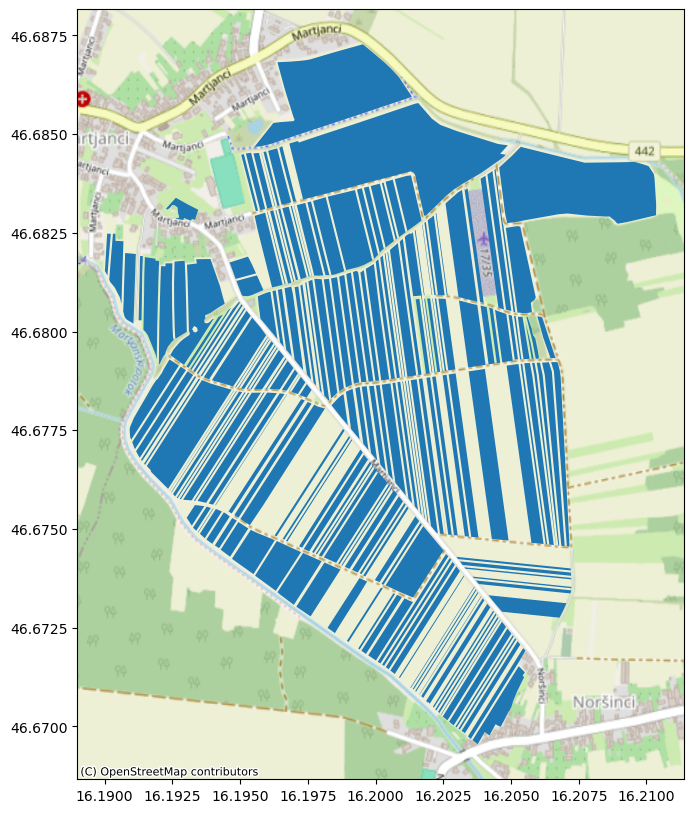

In [4]:
# Izriši polja
agriculture_fields.plot(figsize=(10, 10))
# Dodaj basemap
ctx.add_basemap(plt.gca(), crs=agriculture_fields.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

In [5]:
# Dodaj v stats_df stolpec Šifrant_Naziv iz agriculture_fields, poveži field_id z indeksom agriculture_fields
stats_df = stats_df.merge(agriculture_fields[['Šifrant_Naziv']], left_on='field_id', right_index=True, how='left')
stats_df.head()

,ndre mean,ndvi mean,msavi mean,rtvicore mean,date,day_of_year,field_id,Šifrant_Naziv
0,0.431198,0.602005,0.750235,178666.090426,2020-04-01,92,0,pšenica (ozimna)
1,0.432914,0.607265,0.754640,189198.111702,2020-04-04,95,0,pšenica (ozimna)
2,0.449252,0.641954,0.780817,186626.276596,2020-04-08,99,0,pšenica (ozimna)
3,0.498968,0.666753,0.797947,199615.106383,2020-04-22,113,0,pšenica (ozimna)
4,0.504292,0.681318,0.809268,201671.250000,2020-04-23,114,0,pšenica (ozimna)


In [6]:
stats_df.dtypes

ndre mean               float64
ndvi mean               float64
msavi mean              float64
rtvicore mean           float64
date             datetime64[us]
day_of_year               int64
field_id                  int64
Šifrant_Naziv               str
dtype: object

In [7]:
# Stolpci
target_col = "Šifrant_Naziv"
id_col = "field_id"
time_col = "date"

ts_cols = ["ndre mean", "ndvi mean", "msavi mean", "rtvicore mean"]

In [8]:
# Osnovne preverbe
print("Manjkajoče vrednosti po stolpcih:")
display(stats_df[[id_col, time_col, target_col] + ts_cols].isna().sum())

Manjkajoče vrednosti po stolpcih:


field_id         0
date             0
Šifrant_Naziv    0
ndre mean        0
ndvi mean        0
msavi mean       0
rtvicore mean    0
dtype: int64

In [9]:
# Preveri unikatne razrede v target_col
print("\nUnikatni razredi:")
display(stats_df.groupby(id_col)[target_col].first().value_counts().rename("n_series"))


Unikatni razredi:


Šifrant_Naziv
pšenica (ozimna)           79
koruza za zrnje            49
ječmen (ozimni)            26
koruza za silažo           23
oljna buča                 12
trajno travinje             7
rž (ozimna)                 5
oljna ogrščica (ozimna)     4
praha                       2
sončnice                    2
krompir-pozni op.12         2
proso                       1
pira (ozimna)               1
oves (jari)                 1
ajda - medonosna praha      1
krmna ogrščica (ozimna)     1
konoplja                    1
Name: n_series, dtype: int64

In [10]:
# Preveri, da vsak field_id pripada samo enemu razredu
label_consistency = stats_df.groupby(id_col)[target_col].nunique()
bad_ids = label_consistency[label_consistency > 1]

if len(bad_ids) > 0:
    print("Opozorilo: nekateri field_id imajo več kot eno oznako")
    display(bad_ids)
else:
    print("V redu: vsak field_id ima natanko eno oznako")

V redu: vsak field_id ima natanko eno oznako


## Zgradi eno časovno vrsto za vsak `field_id`

Vsak vzorec postane matrika oblike:

`(časovni_koraki, število_značilk)`

kjer so značilke:
- `ndre mean`
- `ndvi mean`
- `msavi mean`
- `rtvicore mean`

In [11]:
series_list = []
labels = []
field_ids = []

for field_id, g in stats_df.groupby(id_col, sort=False):
    g = g.sort_values(time_col)
    X_ts = g[ts_cols].to_numpy(dtype=float)
    y = g[target_col].iloc[0]

    series_list.append(X_ts)
    labels.append(y)
    field_ids.append(field_id)

print(f"Število serij: {len(series_list)}")
print(f"Oblika prve serije: {series_list[0].shape}")

Število serij: 217
Oblika prve serije: (26, 4)


In [12]:
# Pregled števila primerov po razredih na ravni serij
series_labels = pd.Series(labels, name="class")
class_counts = series_labels.value_counts()

display(class_counts)

# Ker so nekateri razredi zelo majhni, lahko obdržimo samo razrede
# z vsaj N serijami. Po potrebi spremenite MIN_SERIES_PER_CLASS.
MIN_SERIES_PER_CLASS = 5

keep_classes = class_counts[class_counts >= MIN_SERIES_PER_CLASS].index
keep_mask = series_labels.isin(keep_classes).to_numpy()

series_list_filtered = [x for x, keep in zip(series_list, keep_mask) if keep]
labels_filtered = series_labels[keep_mask].tolist()
field_ids_filtered = [fid for fid, keep in zip(field_ids, keep_mask) if keep]

print(f"Ohranjenih serij: {len(series_list_filtered)} v {len(set(labels_filtered))} razredih")
print("Odstranjeni razredi:")
display(class_counts[class_counts < MIN_SERIES_PER_CLASS])

class
pšenica (ozimna)           79
koruza za zrnje            49
ječmen (ozimni)            26
koruza za silažo           23
oljna buča                 12
trajno travinje             7
rž (ozimna)                 5
oljna ogrščica (ozimna)     4
praha                       2
sončnice                    2
krompir-pozni op.12         2
proso                       1
pira (ozimna)               1
oves (jari)                 1
ajda - medonosna praha      1
krmna ogrščica (ozimna)     1
konoplja                    1
Name: count, dtype: int64

Ohranjenih serij: 201 v 7 razredih
Odstranjeni razredi:


class
oljna ogrščica (ozimna)    4
praha                      2
sončnice                   2
krompir-pozni op.12        2
proso                      1
pira (ozimna)              1
oves (jari)                1
ajda - medonosna praha     1
krmna ogrščica (ozimna)    1
konoplja                   1
Name: count, dtype: int64

In [13]:
# Pretvorba v podatkovni format za tslearn
X = to_time_series_dataset(series_list_filtered)  # shape: (n_samples, max_len, n_features)
y = np.array(labels_filtered)

print("Oblika X:", X.shape)
print("Oblika y:", y.shape)

# Kodiranje razredov
le = LabelEncoder()
y_enc = le.fit_transform(y)

print("Kodirani razredi:")
for i, cls in enumerate(le.classes_):
    print(i, "->", cls)

Oblika X: (201, 26, 4)
Oblika y: (201,)
Kodirani razredi:
0 -> ječmen (ozimni)
1 -> koruza za silažo
2 -> koruza za zrnje
3 -> oljna buča
4 -> pšenica (ozimna)
5 -> rž (ozimna)
6 -> trajno travinje


In [14]:
# Delitev na učni in testni del na ravni SERIJ
X_train, X_test, y_train, y_test, fid_train, fid_test = train_test_split(
    X,
    y_enc,
    field_ids_filtered,
    test_size=0.2,
    random_state=42,
    stratify=y_enc
)

print("Velikost učnega dela:", len(X_train))
print("Velikost testnega dela:", len(X_test))

Velikost učnega dela: 160
Velikost testnega dela: 41


## Učenje klasifikatorja `tslearn`

Začetek je preprost in dober osnovni model:
- `KNeighborsTimeSeriesClassifier`
- `metric="dtw"`

Kasneje lahko poskusite tudi:
- `metric="softdtw"`
- `TimeSeriesSVC`
- ekstrakcijo značilk + klasični sklearn klasifikato

In [15]:
clf = KNeighborsTimeSeriesClassifier(
    n_neighbors=3,
    metric="dtw"
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))

                  precision    recall  f1-score   support

 ječmen (ozimni)       0.50      0.40      0.44         5
koruza za silažo       0.67      0.80      0.73         5
 koruza za zrnje       0.69      0.90      0.78        10
      oljna buča       1.00      0.33      0.50         3
pšenica (ozimna)       0.75      0.75      0.75        16
     rž (ozimna)       0.00      0.00      0.00         1
 trajno travinje       1.00      1.00      1.00         1

        accuracy                           0.71        41
       macro avg       0.66      0.60      0.60        41
    weighted avg       0.70      0.71      0.69        41



c:\Users\krost\miniforge3\envs\planeteo\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\krost\miniforge3\envs\planeteo\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\krost\miniforge3\envs\planeteo\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

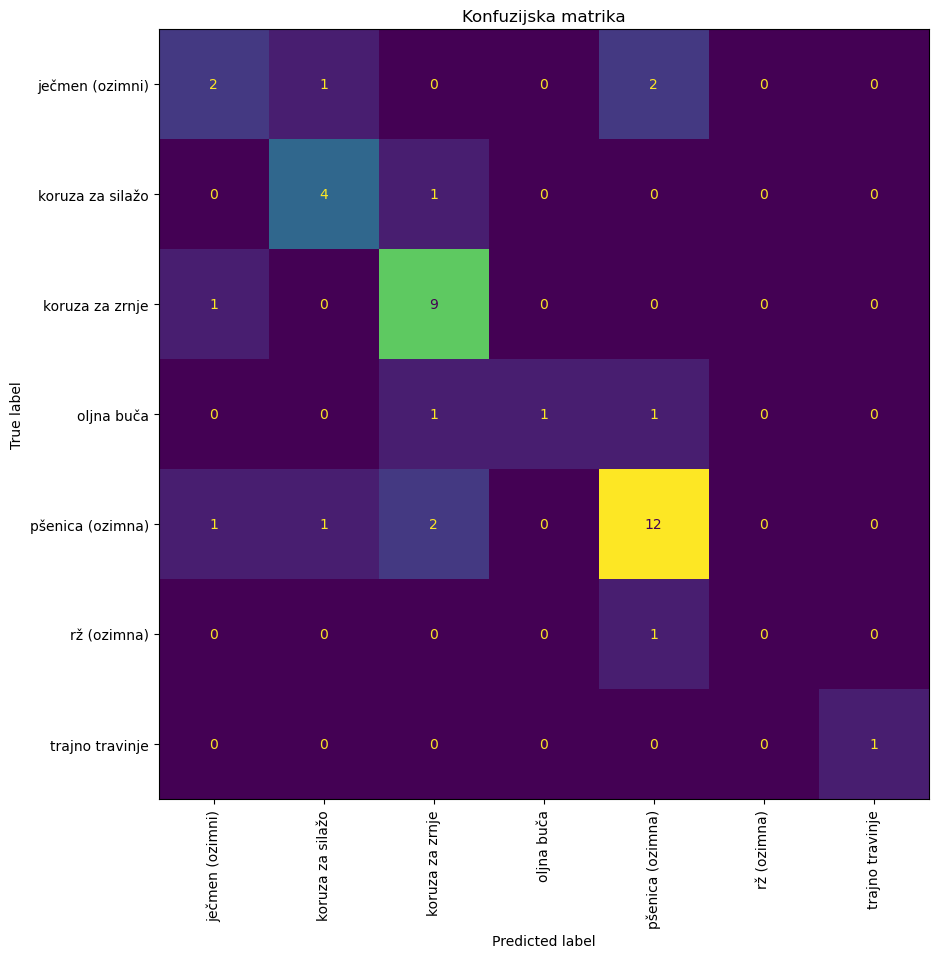

In [16]:
# Matrika zamenjav
fig, ax = plt.subplots(figsize=(10, 10))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Konfuzijska matrika")
plt.show()

In [17]:
# Prikaži napovedi skupaj z field_id
results = pd.DataFrame({
    "field_id": fid_test,
    "true_label": le.inverse_transform(y_test),
    "pred_label": le.inverse_transform(y_pred)
}).sort_values(["true_label", "field_id"])

display(results.head(20))

,field_id,true_label,pred_label
12,39,ječmen (ozimni),ječmen (ozimni)
31,67,ječmen (ozimni),ječmen (ozimni)
22,85,ječmen (ozimni),pšenica (ozimna)
0,115,ječmen (ozimni),koruza za silažo
6,137,ječmen (ozimni),pšenica (ozimna)
17,76,koruza za silažo,koruza za silažo
18,78,koruza za silažo,koruza za silažo
33,99,koruza za silažo,koruza za silažo
4,204,koruza za silažo,koruza za zrnje
30,215,koruza za silažo,koruza za silažo


In [18]:
# Napovej razred za vsa polja z razredi, ki so bili uporabljeni pri učenju
X_all = to_time_series_dataset(series_list_filtered)
y_pred_all = clf.predict(X_all)

all_results = pd.DataFrame({
    "field_id": field_ids_filtered,
    "pred_label": le.inverse_transform(y_pred_all),
    "true_label": labels_filtered
})

print(f"Napovedi za {len(all_results)} polj ({len(set(labels_filtered))} razredov):")
display(all_results)

Napovedi za 201 polj (7 razredov):


,field_id,pred_label,true_label
0,0,pšenica (ozimna),pšenica (ozimna)
1,1,pšenica (ozimna),pšenica (ozimna)
2,2,pšenica (ozimna),pšenica (ozimna)
3,3,koruza za silažo,koruza za silažo
4,4,pšenica (ozimna),pšenica (ozimna)
...,...,...,...
196,212,koruza za zrnje,koruza za zrnje
197,213,trajno travinje,trajno travinje
198,214,pšenica (ozimna),pšenica (ozimna)
199,215,koruza za silažo,koruza za silažo


In [19]:
# Dodaj pred_label oznake originalnim agriculture_fields (za vsa polja)
agriculture_fields["pred_label"] = agriculture_fields.index.map(
    all_results.set_index("field_id")["pred_label"]
)
agriculture_fields.head(20)

,Šifrant_Naziv,geometry,pred_label
0,pšenica (ozimna),"MULTIPOLYGON (((16.19521 46.68451, 16.1954 46....",pšenica (ozimna)
1,pšenica (ozimna),"MULTIPOLYGON (((16.19874 46.67408, 16.20058 46...",pšenica (ozimna)
2,pšenica (ozimna),"MULTIPOLYGON (((16.19779 46.67437, 16.1999 46....",pšenica (ozimna)
3,koruza za silažo,"MULTIPOLYGON (((16.20372 46.67345, 16.2014 46....",koruza za silažo
4,pšenica (ozimna),"MULTIPOLYGON (((16.2 46.67875, 16.19944 46.681...",pšenica (ozimna)
5,pšenica (ozimna),"MULTIPOLYGON (((16.19701 46.68112, 16.19715 46...",pšenica (ozimna)
6,pšenica (ozimna),"MULTIPOLYGON (((16.1974 46.68124, 16.19745 46....",pšenica (ozimna)
7,pšenica (ozimna),"MULTIPOLYGON (((16.19503 46.67856, 16.19616 46...",pšenica (ozimna)
8,pšenica (ozimna),"MULTIPOLYGON (((16.19846 46.6782, 16.19863 46....",pšenica (ozimna)
9,pšenica (ozimna),"MULTIPOLYGON (((16.19862 46.67412, 16.2005 46....",pšenica (ozimna)


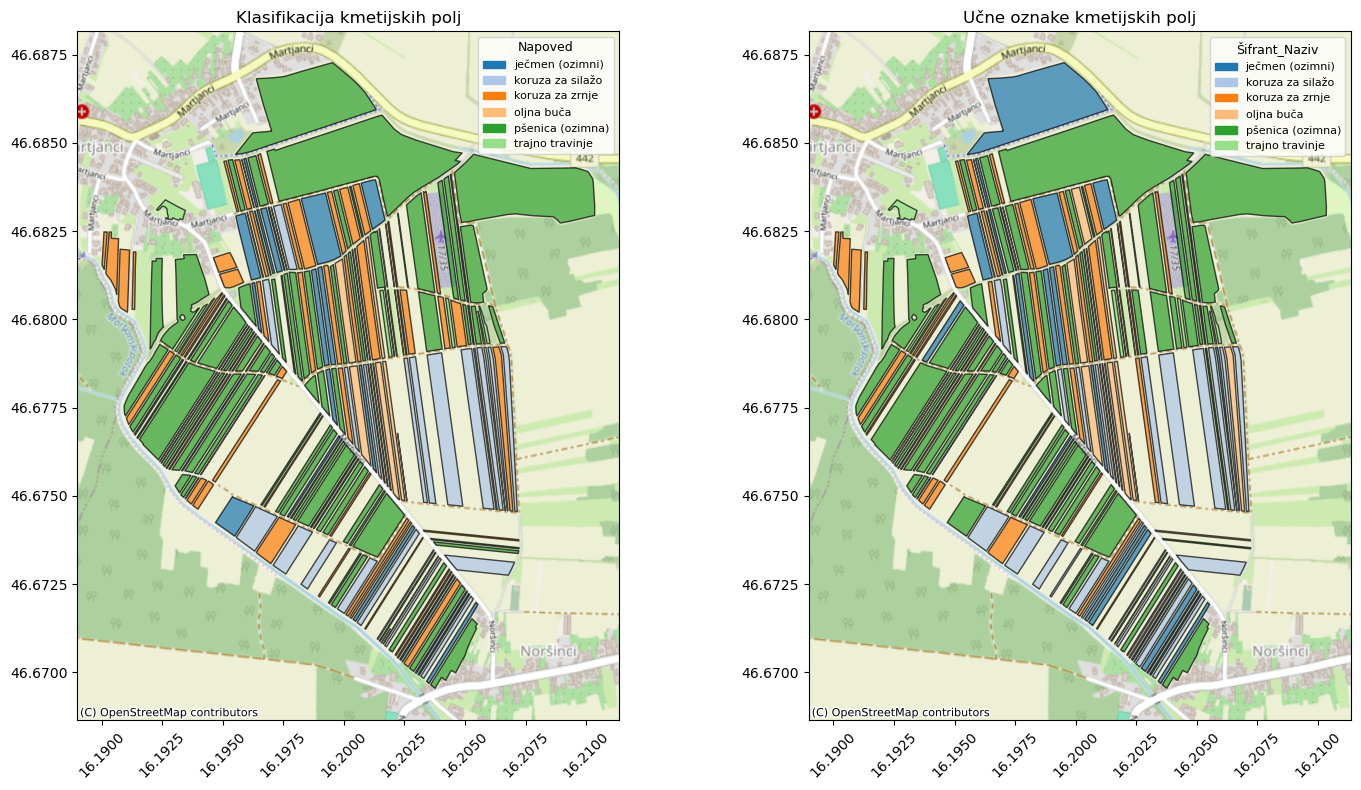

In [20]:
# Skupna barvna legenda za napovedane razrede
import matplotlib.patches as mpatches

pred_classes = sorted(agriculture_fields['pred_label'].dropna().unique())
cmap_shared = plt.get_cmap('tab20')
color_map = {cls: cmap_shared(i % cmap_shared.N) for i, cls in enumerate(pred_classes)}
true_filtered = agriculture_fields[agriculture_fields['Šifrant_Naziv'].isin(pred_classes)].copy()
patches = [mpatches.Patch(color=color_map[c], label=c) for c in pred_classes]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))

# Levo: napovedane oznake
for cls in pred_classes:
    subset = agriculture_fields[agriculture_fields['pred_label'] == cls]
    subset.plot(ax=ax1, facecolor=color_map[cls], edgecolor='black', alpha=0.7)
ctx.add_basemap(ax1, crs=agriculture_fields.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
ax1.legend(handles=patches, title='Napoved', loc='upper right', fontsize=8, title_fontsize=9)
ax1.set_title('Klasifikacija kmetijskih polj')
ax1.tick_params(axis='x', labelrotation=45)

# Desno: učne oznake
for cls in pred_classes:
    subset = true_filtered[true_filtered['Šifrant_Naziv'] == cls]
    subset.plot(ax=ax2, facecolor=color_map[cls], edgecolor='black', alpha=0.7)
ctx.add_basemap(ax2, crs=agriculture_fields.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
ax2.legend(handles=patches, title='Šifrant_Naziv', loc='upper right', fontsize=8, title_fontsize=9)
ax2.set_title('Učne oznake kmetijskih polj')
ax2.tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()